In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mirichoi0218_insurance_path = kagglehub.dataset_download('mirichoi0218/insurance')

print('Data source import complete.')


Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/insurance/insurance.csv


In [ ]:
# Read the dataset
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')

# Display the first few rows of the dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Summary statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Null Count
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


<Axes: xlabel='charges', ylabel='Density'>

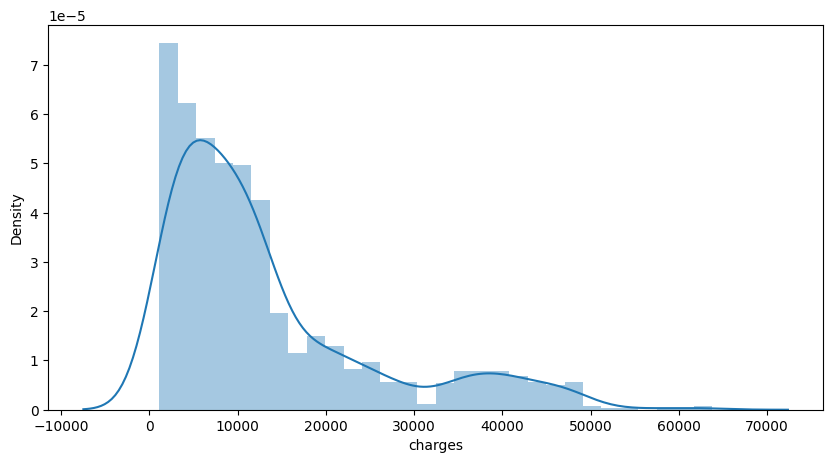

In [ ]:
plt.figure(figsize = (10,5))
sns.distplot(df['charges'])

In [ ]:
df[df.duplicated()]
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
print ("\nUnique values :  \n", df.nunique())


Unique values :  
 age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


In [ ]:
df['sex'].value_counts()

,count
sex,
male,676
female,662


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [ ]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

## **old encoding**

In [ ]:
# region_dict = {
#     'southwest':0,
#     'southeast':1,
#     'northwest':2,
#     'northeast':3
# }

# df['region'] = df['region'].map(region_dict).astype(int)

# df.head()

In [ ]:
# sex_dict = {
#     'female':0,
#     'male':1
# }

# df['sex'] = df['sex'].map(sex_dict).astype(int)

# df.head()

In [ ]:
# smoker_dict = {
#     'yes':1,
#     'no':0
# }

# df['smoker'] = df['smoker'].map(smoker_dict).astype(int)

# df.head()

In [ ]:
# df.info()

In [ ]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]
df_no_outliers

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## **Better encoding**

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# creating column transformer (this will help us normalize/preprocess our data)

ct = make_column_transformer(
                            (MinMaxScaler(), ['age', 'bmi', 'children']),
                            (OneHotEncoder(handle_unknown = 'ignore'), ['sex', 'smoker', 'region'])
)

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
# creating X and y (features and labels)

X = df.drop('charges', axis = 1)
y = df['charges']

In [ ]:
# splitting data into training set and test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

In [ ]:
# fitting column transformer on training data
ct.fit(X_train)

# transforming training and test data with normalizing (MinMaxScaler) and one hot encodig (OneHotEncoder)
X_train = ct.transform(X_train)
X_test = ct.transform(X_test)

## **Helper Functions**

In [ ]:
def evaluate_regression_model(model, X_test, y_test):
  """
  Evaluates a regression model and prints its performance metrics.

  Args:
    model: The trained regression model.
    X_test: The test features.
    y_test: The true test labels.
  """
  y_pred = model.predict(X_test)
  accuracy = model.score(X_test, y_test)
  r2 = r2_score(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_pred)

  print(f'Accuracy = {accuracy:.4f}')
  print(f'R2 Score = {r2:.4f}')
  print(f'Mean Squared Error (MSE) = {mse:.2f}')
  print(f'Root Mean Squared Error (RMSE) = {rmse:.2f}')
  print(f'Mean Absolute Error (MAE) = {mae:.2f}')

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = model.score(X_test, y_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    print("\n\nScore Table is: ")
    score_df = pd.DataFrame([[f'{accuracy:.4f}', f'{r2:.4f}', f'{mse:.2f}', f'{rmse:.2f}', f'{mae:.2f}']],
                            columns=["accuracy", "R2", "MSE", "RMSE", "MAE"])

    return score_df

## **Linear Regression** #

In [ ]:
# Training the Model
regressor = LinearRegression()
result = train_model(regressor, X_train, y_train, X_test, y_test)
result.index=["Linear Regression"]
result



Score Table is: 


,accuracy,R2,MSE,RMSE,MAE
Linear Regression,0.7836,0.7836,33596915.85,5796.28,4181.19


## **Gradient Boosting Model** #

In [ ]:
Gradient_model = GradientBoostingRegressor()
GB = train_model(Gradient_model, X_train, y_train, X_test, y_test)
GB.index = ["Gradient Boosting"]
result = pd.concat([result, GB])

result



Score Table is: 


,accuracy,R2,MSE,RMSE,MAE
Linear Regression,0.7836,0.7836,33596915.85,5796.28,4181.19
Gradient Boosting,0.8789,0.8789,18799221.64,4335.81,2411.42


## **XGB Model**

In [ ]:
XGB_model = XGBRegressor()
XGB = train_model(XGB_model, X_train, y_train, X_test, y_test)
XGB.index = ["XGB"]
result = pd.concat([result, XGB])

result



Score Table is: 


,accuracy,R2,MSE,RMSE,MAE
Linear Regression,0.7836,0.7836,33596915.85,5796.28,4181.19
Gradient Boosting,0.8789,0.8789,18799221.64,4335.81,2411.42
XGB,0.8554,0.8554,22454421.07,4738.61,2604.33


## **KNN Model**

In [ ]:
# Training the KNN Model
knn_model = KNeighborsRegressor()
KNN = train_model(knn_model, X_train, y_train, X_test, y_test)
KNN.index = ["KNN"]
result = pd.concat([result, KNN])

result



Score Table is: 


,accuracy,R2,MSE,RMSE,MAE
Linear Regression,0.7836,0.7836,33596915.85,5796.28,4181.19
Gradient Boosting,0.8789,0.8789,18799221.64,4335.81,2411.42
XGB,0.8554,0.8554,22454421.07,4738.61,2604.33
KNN,0.7860,0.7860,33220062.50,5763.68,3599.65


## **Polynomial Regression model**

In [ ]:
# Create polynomial features
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [ ]:
# Train the Polynomial Regression model
poly_regressor = LinearRegression()
p_reg = train_model(poly_regressor, X_train_poly, y_train, X_test_poly, y_test)
p_reg.index = ["Polynomial Regression"]
result = pd.concat([result, p_reg])

result




Score Table is: 


,accuracy,R2,MSE,RMSE,MAE
Linear Regression,0.7836,0.7836,33596915.85,5796.28,4181.19
Gradient Boosting,0.8789,0.8789,18799221.64,4335.81,2411.42
XGB,0.8554,0.8554,22454421.07,4738.61,2604.33
KNN,0.7860,0.7860,33220062.50,5763.68,3599.65
Polynomial Regression,0.8666,0.8666,20712805.99,4551.13,2729.50


## **Random Forest Model**

In [ ]:
# Train the Rndome Froest Model
Random_model = RandomForestRegressor()
RF = train_model(Random_model, X_train, y_train, X_test, y_test)
RF.index = ["Random Forest"]
result = pd.concat([result, RF])

result



Score Table is: 


,accuracy,R2,MSE,RMSE,MAE
Linear Regression,0.7836,0.7836,33596915.85,5796.28,4181.19
Gradient Boosting,0.8789,0.8789,18799221.64,4335.81,2411.42
XGB,0.8554,0.8554,22454421.07,4738.61,2604.33
KNN,0.7860,0.7860,33220062.50,5763.68,3599.65
Polynomial Regression,0.8666,0.8666,20712805.99,4551.13,2729.50
Random Forest,0.8606,0.8606,21634331.65,4651.27,2564.29
